## Importing Libraries

In [352]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Loading and Dataset

In [353]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# **Helper Functions**

In [354]:
def compute_error(X, y, w):
    """
    Calculating error of Predicted vs Actual
    """
    y_hat = X @ w
    return (y_hat - y)

In [355]:
def add_bias(X):
    """
    Adding the intercept column
    """

    return np.column_stack([np.ones((X.shape[0], 1)), X])

In [356]:
def encode(fb):
    df_enc = df.copy()

    for i in fb:
        if pd.api.types.is_string_dtype(df_enc[i]):
            df_enc[i] = df_enc[i].map({'yes': 1, 'no': 0})

    X = df_enc[fb].values.astype(float)
    Y = df_enc['price'].values.astype(float)

    X_train_raw, X_val_raw, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42, shuffle=True)

    return X_train_raw, X_val_raw, Y_train, Y_val

In [357]:
def compute_loss(X, y, w):
    """
    Computing the MSE Loss using the following formula: (1 / (2m)) * sum((y_hat - y)^2)
    """

    m = len(y)
    error = compute_error(X, y, w)
    return ((1 / (2*m)) * np.sum((error) **2))

In [358]:
def compute_gradient_descent(X, y, w):
    """
    Computing gradient descent wrt w using a tain/val split of 80/20
    """

    m = len(y)
    error = compute_error(X, y, w)

    return ((1/m) * (X.T @ error))

In [359]:
def train_model(train_X, train_Y, val_X, val_Y, lr, n):
    """
    Training a linear regression model with gradient descent
    """

    # Initializing wieghts to 0
    w = np.zeros(train_X.shape[1])
    
    train_loss = []
    val_loss = []

    # Training Loop
    for i in range(n):
        gradient = compute_gradient_descent(train_X, train_Y, w)

        #Updating weights
        w = w - (lr * gradient)

        train_loss.append(compute_loss(train_X, train_Y, w))
        val_loss.append(compute_loss(val_X, val_Y, w))
    
    return w, np.array(train_loss), np.array(val_loss)

## Plot Helper Functions

In [360]:
def plot_loss(train_loss, val_loss, lr, title):
    plt.figure(figsize=(8, 4))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss,   label='Validation Loss')
    plt.xlabel('Iteration')
    plt.ylabel('MSE Loss')
    lbl = f'{title}' + (f'  (lr={lr})' if lr else '')
    plt.title(lbl)
    plt.legend()
    plt.tight_layout()
    plt.show()

# **Problem 1**

In [361]:
# Selecting required features for both parts of the Question
feature_a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

features_b = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

# Converting into a 2D array
X_a = df[feature_a].values.astype(float)
Y_a = df['price'].values.astype(float)

# Splitting the dataset as required
X_train_a_raw, X_val_a_raw, Y_train_a_raw, Y_val_a_raw = train_test_split(X_a, Y_a, test_size=0.2, random_state=42, shuffle=True)

# Scaling to prevent divergence issue
X_max_a = X_train_a_raw.max(axis=0)
Y_max_a = Y_train_a_raw.max()

X_train_1a_raw = X_train_a_raw / X_max_a
X_val_1a_raw = X_val_a_raw / X_max_a
Y_train_1a = Y_train_a_raw / Y_max_a
Y_val_1a = Y_val_a_raw / Y_max_a

# Adding the bias column
X_train_1a = add_bias(X_train_1a_raw)
X_val_1a = add_bias(X_val_1a_raw)

print(f"Train: {X_train_1a.shape}, Val: {X_val_1a.shape}")

# Initializing lr and iterations

learning_rate = [0.1, 0.07, 0.05, 0.03, 0.01]
n = 2000

Train: (436, 6), Val: (109, 6)


## Part 1(a)

In [362]:
results_1a = {}

for i in learning_rate:
    w, train_loss, val_loss = train_model(X_train_1a, Y_train_1a, X_val_1a, Y_val_1a, i, n)

    results_1a[i] = (w, train_loss, val_loss)
    print(f"lr={i:4.2f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

lr=0.10 | Final Train Loss: 4.5069e-03 | Final Val Loss: 7.6522e-03
lr=0.07 | Final Train Loss: 4.5356e-03 | Final Val Loss: 7.7169e-03
lr=0.05 | Final Train Loss: 4.6033e-03 | Final Val Loss: 7.8515e-03
lr=0.03 | Final Train Loss: 4.8090e-03 | Final Val Loss: 8.2236e-03
lr=0.01 | Final Train Loss: 5.5188e-03 | Final Val Loss: 9.5074e-03


### Plotting the Loss Functions for Features A

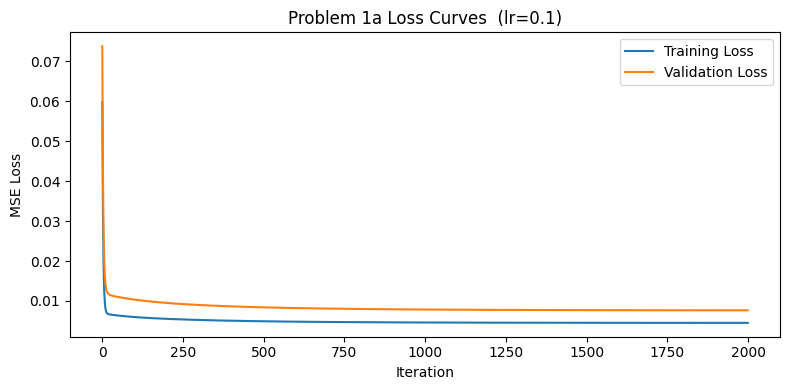

Best Learning Rate: 0.1
Learned Weights:
[0.01  0.394 0.09  0.354 0.164 0.087]


In [363]:
# Plotting the best learning rate 

# Picking the learning rate corresponding to lowest Validation loss
bestLR_1a = min(results_1a, key=lambda i: results_1a[i][2][-1])
w_1a, train_loss_1a, val_loss_1a = results_1a[bestLR_1a]

plot_loss(train_loss_1a, val_loss_1a, bestLR_1a, "Problem 1a Loss Curves")

print(f"Best Learning Rate: {bestLR_1a}")
print(f"Learned Weights:")
print(np.round(w_1a, 3))

## Part 1(b)

In [364]:
X_train_b_raw,  X_val_b_raw, Y_train_b_raw, Y_val_b_raw = encode(features_b)

# Scaling to prevent divergence issue
X_max_b = X_train_b_raw.max(axis=0)
Y_max_b = Y_train_b_raw.max()

X_train_1b_raw = X_train_b_raw / X_max_b
X_val_1b_raw = X_val_b_raw / X_max_b
Y_train_1b = Y_train_b_raw / Y_max_b
Y_val_1b = Y_val_b_raw / Y_max_b

X_train_1b = add_bias(X_train_1b_raw)
X_val_1b = add_bias(X_val_1b_raw)

print(f"Train: {X_train_1b.shape}, Val: {X_val_1b.shape}")

results_1b = {}

for i in learning_rate:
    w, train_loss, val_loss = train_model(X_train_1b, Y_train_1b, X_val_1b, Y_val_1b, i, n)

    results_1b[i] = (w, train_loss, val_loss)
    print(f"lr={i:4.2f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

Train: (436, 12), Val: (109, 12)
lr=0.10 | Final Train Loss: 3.3159e-03 | Final Val Loss: 5.9520e-03
lr=0.07 | Final Train Loss: 3.3421e-03 | Final Val Loss: 5.9492e-03
lr=0.05 | Final Train Loss: 3.3986e-03 | Final Val Loss: 5.9880e-03
lr=0.03 | Final Train Loss: 3.5564e-03 | Final Val Loss: 6.1590e-03
lr=0.01 | Final Train Loss: 4.0659e-03 | Final Val Loss: 6.9490e-03


### Plotting the Loss Functions for Features B

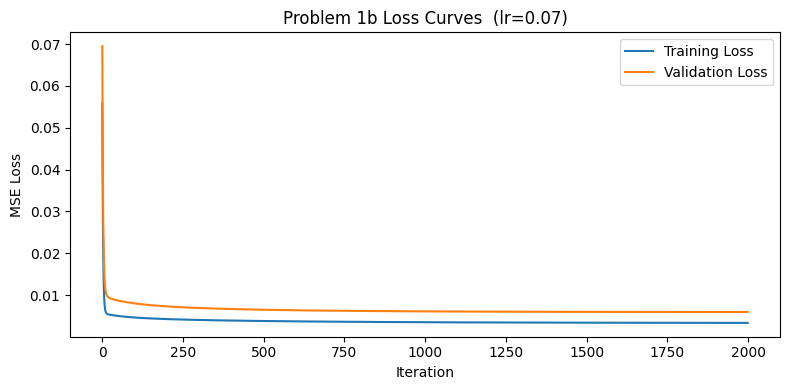

Best Learning Rate: 0.07
Learned Weights:
[0.007 0.279 0.067 0.299 0.14  0.035 0.023 0.035 0.06  0.068 0.069 0.052]


In [365]:
# Plotting the best learning rate 

# Picking the learning rate corresponding to lowest Validation loss
bestLR_1b = min(results_1b, key=lambda i: results_1b[i][2][-1])
w_1b, train_loss_1b, val_loss_1b = results_1b[bestLR_1b]

plot_loss(train_loss_1b, val_loss_1b, bestLR_1b, "Problem 1b Loss Curves")

print(f"Best Learning Rate: {bestLR_1b}")
print(f"Learned Weights:")
print(np.round(w_1b, 3))

### Plotting the Comparison Curves Between Problem 1 Parts

Problem 1a  (lr=0.1)
  Final Train Loss : 4.5069e-03
  Final Val   Loss : 7.6522e-03

Problem 1b (lr=0.07)
  Final Train Loss : 3.3421e-03
  Final Val   Loss : 5.9492e-03


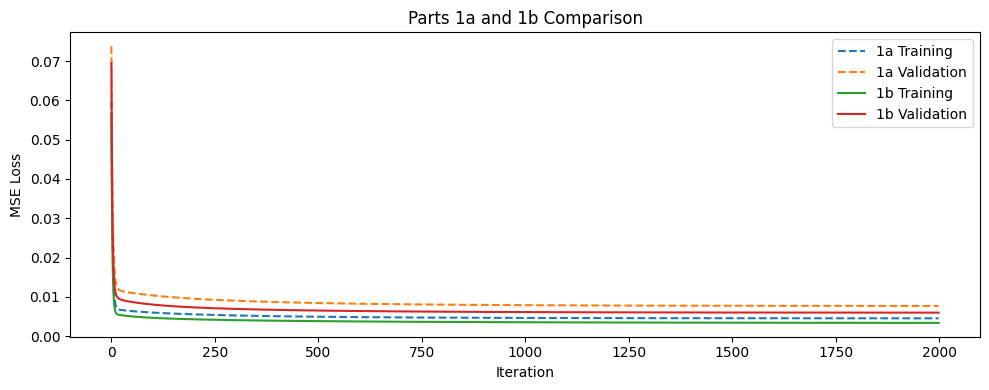

In [366]:
print("=" * 50)
print(f"Problem 1a  (lr={bestLR_1a})")
print(f"  Final Train Loss : {train_loss_1a[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_1a[-1]:.4e}")
print()
print(f"Problem 1b (lr={bestLR_1b})")
print(f"  Final Train Loss : {train_loss_1b[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_1b[-1]:.4e}")
print("=" * 50)

# Side-by-side loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_loss_1a, label='1a Training', linestyle='--')
plt.plot(val_loss_1a, label='1a Validation',   linestyle='--')
plt.plot(train_loss_1b, label='1b Training')
plt.plot(val_loss_1b, label='1b Validation')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Parts 1a and 1b Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# **Problem 2**

In [367]:
# Importing libraries for normalization and standardization
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Initializing the required variables
normal = MinMaxScaler()
std = StandardScaler()

## Part 2a

In [368]:
# Normalizing the data
X_train_norm_2a_raw = normal.fit_transform(X_train_a_raw)
X_val_norm_2a_raw = normal.transform(X_val_a_raw)

#Standardizing the data
X_train_std_2a_raw = std.fit_transform(X_train_a_raw)
X_val_std_2a_raw = std.fit_transform(X_val_a_raw)

# Adding the bias column
X_train_norm_2a = add_bias(X_train_norm_2a_raw)
X_train_std_2a = add_bias(X_train_std_2a_raw)
X_val_norm_2a = add_bias(X_val_norm_2a_raw)
X_val_std_2a = add_bias(X_val_std_2a_raw)

# Transferring variables for readability
Y_train_2a = Y_train_1a
Y_val_2a = Y_val_1a

# Training both sets
results_norm_a = {}
results_std_a = {}

# Normalization training loop
print("=" * 60)
print("Normalization Training")
print("=" * 60)
print("\n")

for i in learning_rate:
    w, train_loss, val_loss = train_model(X_train_norm_2a, Y_train_2a, X_val_norm_2a, Y_val_2a, i, n)

    results_norm_a[i] = (w, train_loss, val_loss)
    print(f"lr={i:4.2f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

print("\n")
print("=" * 60)
print("Standardization Training")
print("=" * 60)
print("\n")

# Standardization training loop
for i in learning_rate:
    w, train_loss, val_loss = train_model(X_train_std_2a, Y_train_2a, X_val_std_2a, Y_val_2a, i, n)

    results_std_a[i] = (w, train_loss, val_loss)
    print(f"lr={i:4.2f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

Normalization Training


lr=0.10 | Final Train Loss: 4.4992e-03 | Final Val Loss: 7.6434e-03
lr=0.07 | Final Train Loss: 4.5052e-03 | Final Val Loss: 7.6625e-03
lr=0.05 | Final Train Loss: 4.5270e-03 | Final Val Loss: 7.7091e-03
lr=0.03 | Final Train Loss: 4.6287e-03 | Final Val Loss: 7.8770e-03
lr=0.01 | Final Train Loss: 5.1848e-03 | Final Val Loss: 8.8287e-03


Standardization Training


lr=0.10 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03
lr=0.07 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03
lr=0.05 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03
lr=0.03 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03
lr=0.01 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03


### Plotting the Loss Functions for Normalization and Standardization

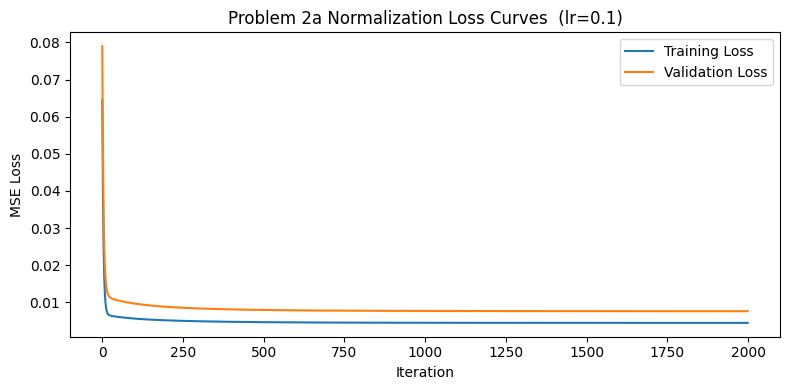

Best lr: 0.1
Weights:
[0.194 0.361 0.07  0.285 0.121 0.084]


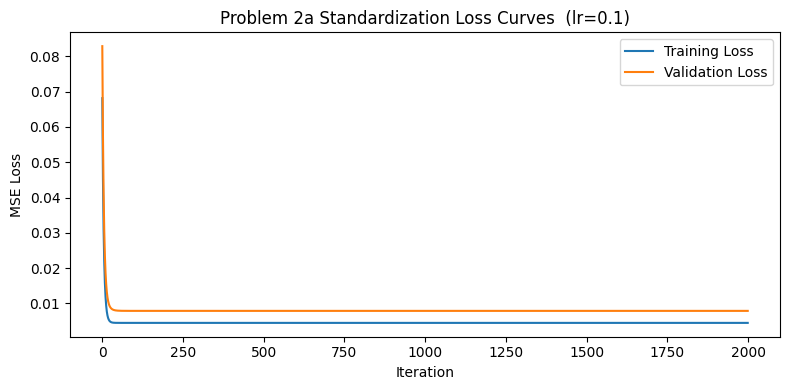

Best lr: 0.1
Weights:
[0.384 0.056 0.009 0.046 0.035 0.024]


In [369]:
# Extracting the best learning rates and corresponding parameters
# Normalization
bestLR_norm_2a = min(results_norm_a, key=lambda i: results_norm_a[i][2][-1])
w_norm_2a, train_loss_norm_2a, val_loss_norm_2a = results_norm_a[bestLR_norm_2a]

plot_loss(train_loss_norm_2a, val_loss_norm_2a, bestLR_norm_2a, "Problem 2a Normalization Loss Curves")

print(f"Best lr: {bestLR_norm_2a}")
print(f"Weights:\n{np.round(w_norm_2a, 3)}")

# Standardization
bestLR_std_2a = min(results_std_a, key=lambda i: results_std_a[i][2][-1])
w_std_2a, train_loss_std_2a, val_loss_std_2a = results_std_a[bestLR_std_2a]

plot_loss(train_loss_std_2a, val_loss_std_2a, bestLR_std_2a, "Problem 2a Standardization Loss Curves")

print(f"Best lr: {bestLR_std_2a}")
print(f"Weights:\n{np.round(w_std_2a, 3)}")

### Plotting the Comparison Curves Between Normalization and Standardization

Problem 2a Normalization (lr=0.1)
  Final Train Loss : 4.4992e-03
  Final Val   Loss : 7.6434e-03

Problem 2a Standardization (lr=0.1)
  Final Train Loss : 4.4982e-03
  Final Val   Loss : 7.9018e-03


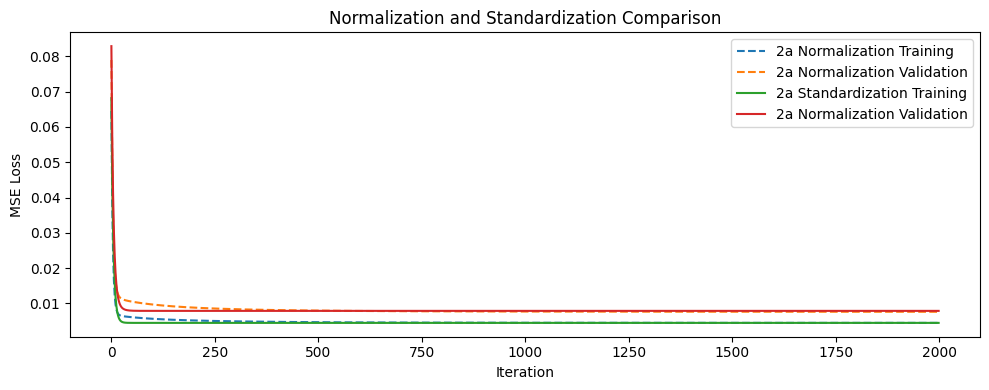

In [370]:
print("=" * 50)
print(f"Problem 2a Normalization (lr={bestLR_norm_2a})")
print(f"  Final Train Loss : {train_loss_norm_2a[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_norm_2a[-1]:.4e}")
print()
print(f"Problem 2a Standardization (lr={bestLR_std_2a})")
print(f"  Final Train Loss : {train_loss_std_2a[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_std_2a[-1]:.4e}")
print("=" * 50)

# Side-by-side loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_loss_norm_2a, label='2a Normalization Training', linestyle='--')
plt.plot(val_loss_norm_2a, label='2a Normalization Validation',   linestyle='--')
plt.plot(train_loss_std_2a, label='2a Standardization Training')
plt.plot(val_loss_std_2a, label='2a Normalization Validation')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Normalization and Standardization Comparison')
plt.legend()
plt.tight_layout()
plt.show()

### Comparing between training accuracies of 1a and 2a

Between all the training accuracies, it seems that the model trained using standardization has the lowest training lowest, however it has the highest validation loss. This implies that the trained model was not able to estimate the prices properly and the data was slighlty overfitted. Now, the normalized model has the second lowest training loss and the lowest validation loss. This is because gradient descent algorithm converges smoother when all the features are bounded and within a defined range.

## Part 2b

In [371]:
# Normalizing the data
X_train_norm_2b_raw = normal.fit_transform(X_train_b_raw)
X_val_norm_2b_raw = normal.transform(X_val_b_raw)

#Standardizing the data
X_train_std_2b_raw = std.fit_transform(X_train_1a_raw)
X_val_std_2b_raw = std.fit_transform(X_val_1a_raw)

# Adding the bias column
X_train_norm_2b = add_bias(X_train_norm_2b_raw)
X_train_std_2b = add_bias(X_train_std_2b_raw)
X_val_norm_2b = add_bias(X_val_norm_2b_raw)
X_val_std_2b = add_bias(X_val_std_2b_raw)

# Transferring variables for readability
Y_train_2b = Y_train_1b
Y_val_2b = Y_val_1b

# Training both sets
results_norm_b = {}
results_std_b = {}

print("=" * 60)
print("Normalization Training")
print("=" * 60)
print("\n")

# Normalization training loop
for i in learning_rate:
    w, train_loss, val_loss = train_model(X_train_norm_2b, Y_train_2b, X_val_norm_2b, Y_val_2b, i, n)

    results_norm_b[i] = (w, train_loss, val_loss)
    print(f"lr={i:4.2f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

print("\n")
print("=" * 60)
print("Standardization Training")
print("=" * 60)
print("\n")

# Standardization training loop
for i in learning_rate:
    w, train_loss, val_loss = train_model(X_train_std_2b, Y_train_2b, X_val_std_2b, Y_val_2b, i, n)

    results_std_b[i] = (w, train_loss, val_loss)
    print(f"lr={i:4.2f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

Normalization Training


lr=0.10 | Final Train Loss: 3.3083e-03 | Final Val Loss: 5.9799e-03
lr=0.07 | Final Train Loss: 3.3148e-03 | Final Val Loss: 5.9598e-03
lr=0.05 | Final Train Loss: 3.3347e-03 | Final Val Loss: 5.9440e-03
lr=0.03 | Final Train Loss: 3.4162e-03 | Final Val Loss: 5.9687e-03
lr=0.01 | Final Train Loss: 3.8461e-03 | Final Val Loss: 6.4785e-03


Standardization Training


lr=0.10 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03
lr=0.07 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03
lr=0.05 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03
lr=0.03 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03
lr=0.01 | Final Train Loss: 4.4982e-03 | Final Val Loss: 7.9018e-03


### Plotting the Loss Functions for Normalization and Standardization

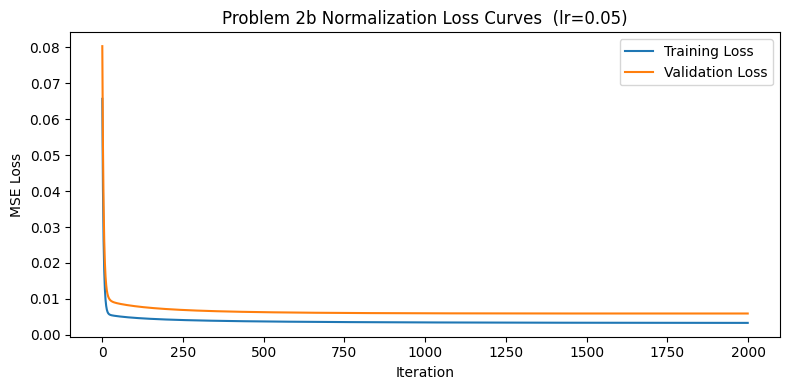

Best lr: 0.05
Weights:
[0.151 0.245 0.066 0.242 0.102 0.038 0.023 0.034 0.059 0.068 0.069 0.053]


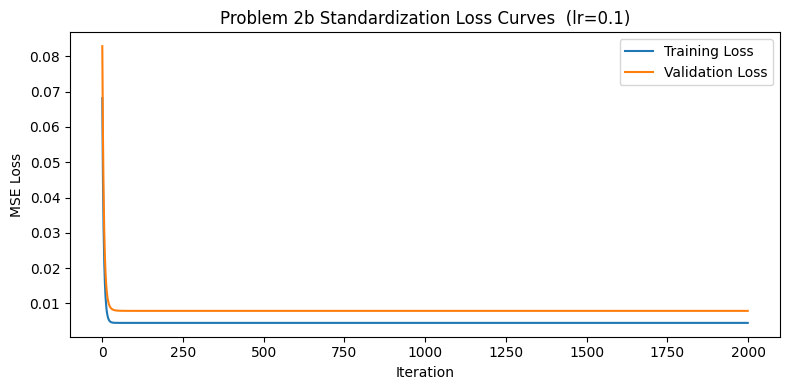

Best lr: 0.1
Weights:
[0.384 0.056 0.009 0.046 0.035 0.024]


In [372]:
# Extracting the best learning rates and corresponding parameters
# Normalization
bestLR_norm_2b = min(results_norm_b, key=lambda i: results_norm_b[i][2][-1])
w_norm_2b, train_loss_norm_2b, val_loss_norm_2b = results_norm_b[bestLR_norm_2b]

plot_loss(train_loss_norm_2b, val_loss_norm_2b, bestLR_norm_2b, "Problem 2b Normalization Loss Curves")

print(f"Best lr: {bestLR_norm_2b}")
print(f"Weights:\n{np.round(w_norm_2b, 3)}")

# Standardization
bestLR_std_2b = min(results_std_b, key=lambda i: results_std_b[i][2][-1])
w_std_2b, train_loss_std_2b, val_loss_std_2b = results_std_b[bestLR_std_2b]

plot_loss(train_loss_std_2b, val_loss_std_2b, bestLR_std_2b, "Problem 2b Standardization Loss Curves")

print(f"Best lr: {bestLR_std_2b}")
print(f"Weights:\n{np.round(w_std_2b, 3)}")

### Plotting the Comparison Curves Between Normalization and Standardization

Problem 2b Normalization (lr=0.05)
  Final Train Loss : 3.3347e-03
  Final Val   Loss : 5.9440e-03

Problem 2b Standardization (lr=0.1)
  Final Train Loss : 4.4982e-03
  Final Val   Loss : 7.9018e-03


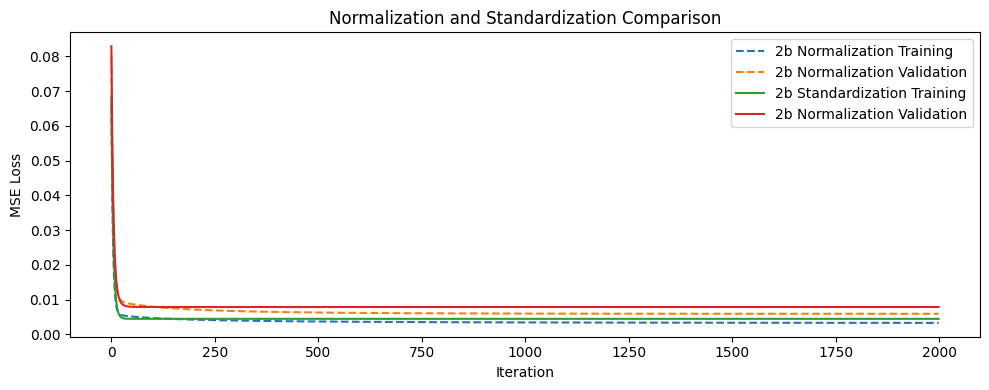

In [373]:
print("=" * 50)
print(f"Problem 2b Normalization (lr={bestLR_norm_2b})")
print(f"  Final Train Loss : {train_loss_norm_2b[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_norm_2b[-1]:.4e}")
print()
print(f"Problem 2b Standardization (lr={bestLR_std_2b})")
print(f"  Final Train Loss : {train_loss_std_2b[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_std_2b[-1]:.4e}")
print("=" * 50)

# Side-by-side loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_loss_norm_2b, label='2b Normalization Training', linestyle='--')
plt.plot(val_loss_norm_2b, label='2b Normalization Validation',   linestyle='--')
plt.plot(train_loss_std_2b, label='2b Standardization Training')
plt.plot(val_loss_std_2b, label='2b Normalization Validation')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Normalization and Standardization Comparison')
plt.legend()
plt.tight_layout()
plt.show()

### Comparing between training accuracies of 1b and 2b

Among the three approaches, the normalized model achieves the lowest training and validation loss. This is consistent with the results seen in Problem 2a, where normalization outperformed both the baseline and standardization. The same reasoning applies where scaling the input features to a [0,1] range allows gradient descent to converge more smoothly and stably, as the features are all non-negative and bounded. 

# **Problem 3**

## Modified Helper Functions

In [374]:
def compute_penalty(lambda_, w, m):
    """
    Computing the penalty needed to add to the gradient descent
    """

    return ((lambda_ / m) * w)

In [375]:
def compute_gradient_descent_penalty(X, y, w, lambda_):
    """
    Modified gradient descent algorithm with penalty parameter
    """

    m = len(y)
    error = compute_error(X, y, w)
    penalty = compute_penalty(lambda_, w, m)

    return ((1 /m) * (X.T @ error) + penalty)

In [376]:
def train_model_penalty(train_X, train_Y, val_X, val_Y, lr, n, lambda_):
    """"
    Modified training function using the gradient descent algorithm with added penalty parameter
    """

    # Initializing weights to 0
    w = np.zeros(train_X.shape[1])

    train_loss = []
    val_loss = []

    # Training loop
    for i in range(n):
        gradient_p = compute_gradient_descent_penalty(train_X, train_Y, w, lambda_)

        # Updating weights
        w = w - (lr * gradient_p)

        train_loss.append(compute_loss(train_X, train_Y, w))
        val_loss.append(compute_loss(val_X, val_Y, w))

    return w, np.array(train_loss), np.array(val_loss)

## Part 3a

In [377]:
lambda_values = [0.001, 0.01, 0.1, 1.0]

# Initializing with new variable names for readability
X_train_3a = X_train_norm_2a
X_val_3a = X_val_norm_2a
Y_train_3a = Y_train_2a
Y_val_3a = Y_val_2a
lr_3a = bestLR_norm_2a

results_3a = {}

print(f"Using a constant learning rate: {lr_3a}\n")
for i in lambda_values:
    w, train_loss, val_loss = train_model_penalty(X_train_3a, Y_train_3a, X_val_3a, Y_val_3a, lr_3a, n, i)

    results_3a[i] = (w, train_loss, val_loss)
    print(f"λ={i:.3f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

Using a constant learning rate: 0.1

λ=0.001 | Final Train Loss: 4.4992e-03 | Final Val Loss: 7.6435e-03
λ=0.010 | Final Train Loss: 4.4992e-03 | Final Val Loss: 7.6442e-03
λ=0.100 | Final Train Loss: 4.5000e-03 | Final Val Loss: 7.6514e-03
λ=1.000 | Final Train Loss: 4.5187e-03 | Final Val Loss: 7.7333e-03


### Plotting the result with the best lambda

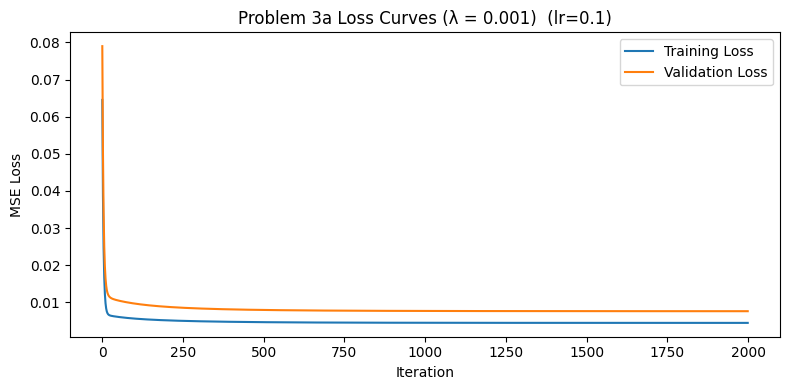

Best λ: 0.001
Weights:
[0.194 0.361 0.07  0.285 0.121 0.084]


In [378]:
# Extracting the best penalty and corresponding parameters
bestλ_3a = min(results_3a, key=lambda i: results_3a[i][2][-1])
w_3a, train_loss_3a, val_loss_3a = results_3a[bestλ_3a]

plot_loss(train_loss_3a, val_loss_3a, lr_3a, f"Problem 3a Loss Curves (λ = {bestλ_3a})")

print(f"Best λ: {bestλ_3a}")
print(f"Weights:\n{np.round(w_3a, 3)}")

### Comparing Loss Curves Between 2a and 3a

Problem 2a Normalization (lr=0.1)
  Final Train Loss : 4.4992e-03
  Final Val   Loss : 7.6434e-03

Problem 3a Regularization (λ=0.001)
  Final Train Loss : 4.4992e-03
  Final Val   Loss : 7.6435e-03


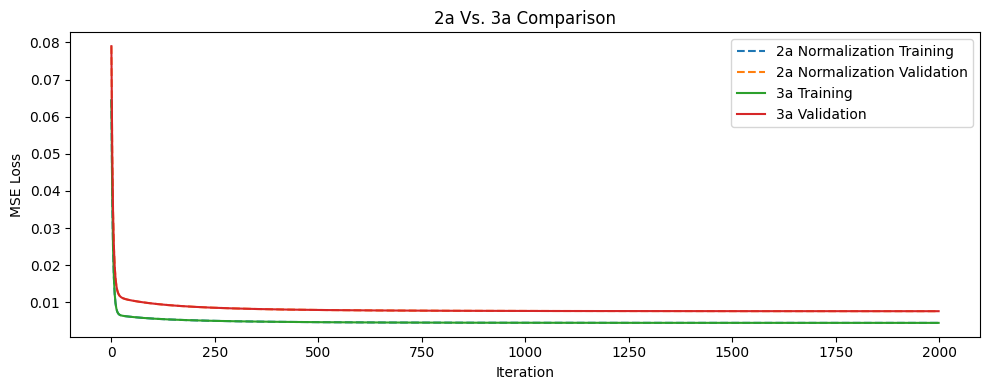

In [379]:
print("=" * 50)
print(f"Problem 2a Normalization (lr={bestLR_norm_2a})")
print(f"  Final Train Loss : {train_loss_norm_2a[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_norm_2a[-1]:.4e}")
print()
print(f"Problem 3a Regularization (λ={bestλ_3a})")
print(f"  Final Train Loss : {train_loss_3a[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_3a[-1]:.4e}")
print("=" * 50)

# Side-by-side loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_loss_norm_2a, label='2a Normalization Training', linestyle='--')
plt.plot(val_loss_norm_2a, label='2a Normalization Validation',   linestyle='--')
plt.plot(train_loss_3a, label='3a Training')
plt.plot(val_loss_3a, label='3a Validation')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('2a Vs. 3a Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## Part 3b

In [380]:
# Initializing with new variable names for readability
X_train_3b = X_train_norm_2b
X_val_3b = X_val_norm_2b
Y_train_3b = Y_train_2b
Y_val_3b = Y_val_2b
lr_3b = bestLR_norm_2b

results_3b = {}

print(f"Using a constant learning rate: {lr_3b}\n")
for i in lambda_values:
    w, train_loss, val_loss = train_model_penalty(X_train_3b, Y_train_3b, X_val_3b, Y_val_3b, lr_3b, n, i)

    results_3b[i] = (w, train_loss, val_loss)
    print(f"λ={i:.3f} | Final Train Loss: {train_loss[-1]:.4e} | Final Val Loss: {val_loss[-1]:.4e}")

Using a constant learning rate: 0.05

λ=0.001 | Final Train Loss: 3.3347e-03 | Final Val Loss: 5.9440e-03
λ=0.010 | Final Train Loss: 3.3349e-03 | Final Val Loss: 5.9442e-03
λ=0.100 | Final Train Loss: 3.3368e-03 | Final Val Loss: 5.9468e-03
λ=1.000 | Final Train Loss: 3.3596e-03 | Final Val Loss: 5.9776e-03


### Plotting the result with the best lambda

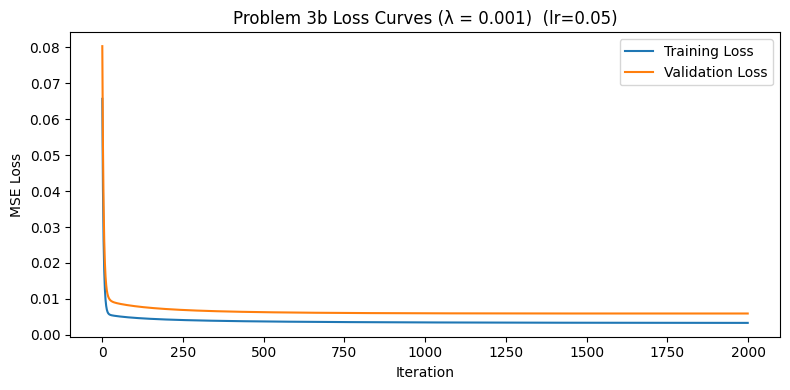

Best λ: 0.001
Weights:
[0.151 0.245 0.066 0.242 0.102 0.038 0.023 0.034 0.059 0.068 0.069 0.053]


In [381]:
# Extracting the best penalty and corresponding parameters
bestλ_3b = min(results_3b, key=lambda i: results_3b[i][2][-1])
w_3b, train_loss_3b, val_loss_3b = results_3b[bestλ_3b]

plot_loss(train_loss_3b, val_loss_3b, lr_3b, f"Problem 3b Loss Curves (λ = {bestλ_3b})")

print(f"Best λ: {bestλ_3b}")
print(f"Weights:\n{np.round(w_3b, 3)}")

### Comparing Loss Curves Between 2b and 3b

Problem 2b Normalization (lr=0.05)
  Final Train Loss : 3.3347e-03
  Final Val   Loss : 5.9440e-03

Problem 3b Regularization (λ=0.001)
  Final Train Loss : 3.3347e-03
  Final Val   Loss : 5.9440e-03


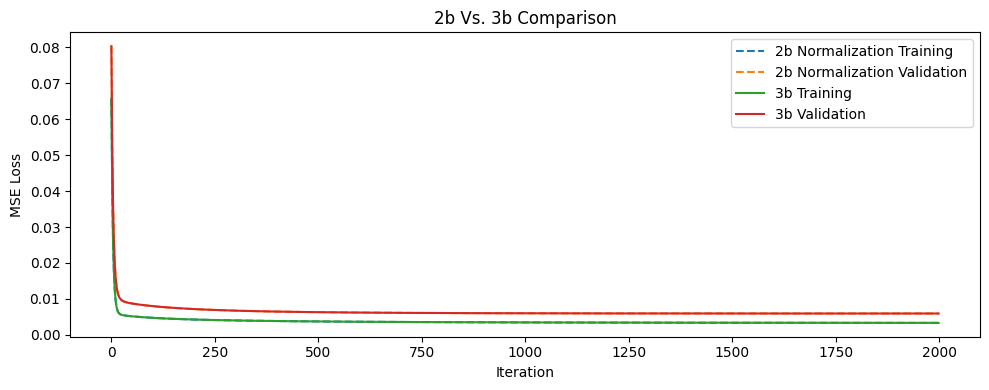

In [382]:
print("=" * 50)
print(f"Problem 2b Normalization (lr={bestLR_norm_2b})")
print(f"  Final Train Loss : {train_loss_norm_2b[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_norm_2b[-1]:.4e}")
print()
print(f"Problem 3b Regularization (λ={bestλ_3b})")
print(f"  Final Train Loss : {train_loss_3b[-1]:.4e}")
print(f"  Final Val   Loss : {val_loss_3b[-1]:.4e}")
print("=" * 50)

# Side-by-side loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_loss_norm_2b, label='2b Normalization Training', linestyle='--')
plt.plot(val_loss_norm_2b, label='2b Normalization Validation',   linestyle='--')
plt.plot(train_loss_3b, label='3b Training')
plt.plot(val_loss_3b, label='3b Validation')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('2b Vs. 3b Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## Explaining Problem 3 Results

In both 3a and 3b, we see that the trained model has the same results as the normalized models trained in 2a and 2b even with the addition of a penalty parameter that introduces regularization. Even though the penalty parameter adds to the gradient descent and is supposed to help balance the weights, the lambda is at such a low value that there is virtually no change to the gradient. This results in the loss function not experiencing any major change thereby producing the overlapping graphs seen above. This implies that at higher lambda values, with a visible change in weights and loss, there is also a higher training and validation cost.